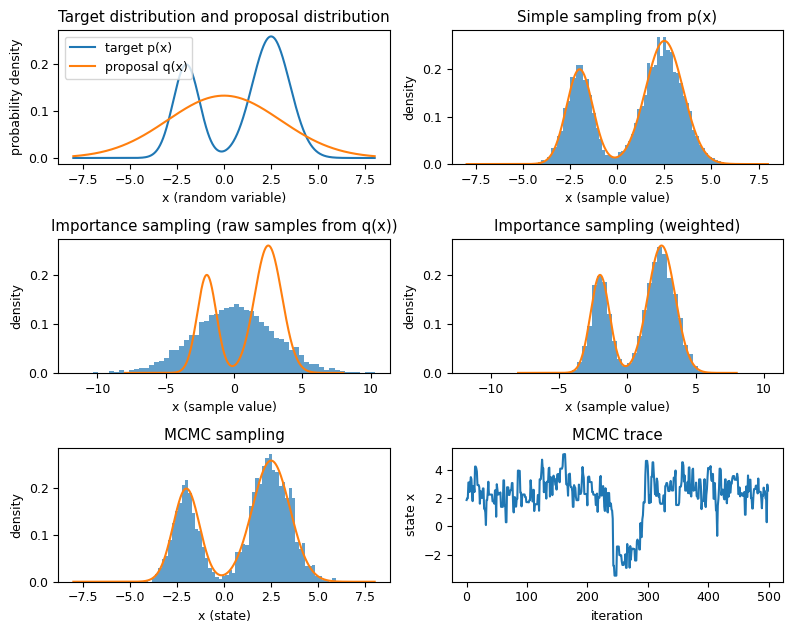

In [3]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------------------------
# 正規分布
# -------------------------------------------------
def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# -------------------------------------------------
# 目的分布（混合正規）
# -------------------------------------------------
def target_pdf(x):
    return 0.35 * normal_pdf(x, -2.0, 0.7) + 0.65 * normal_pdf(x, 2.5, 1.0)

def sample_from_target(n):
    z = np.random.rand(n)
    samples = np.empty(n)

    left = z < 0.35
    right = ~left

    samples[left] = np.random.normal(-2.0, 0.7, left.sum())
    samples[right] = np.random.normal(2.5, 1.0, right.sum())

    return samples

# -------------------------------------------------
# 提案分布
# -------------------------------------------------
Q_MU = 0
Q_SIGMA = 3

def proposal_pdf(x):
    return normal_pdf(x, Q_MU, Q_SIGMA)

def sample_from_proposal(n):
    return np.random.normal(Q_MU, Q_SIGMA, n)

# -------------------------------------------------
# MCMC (Metropolis-Hastings)
# -------------------------------------------------
def metropolis(n, burn=1000, step=1.2):

    x = 0
    samples = []

    for i in range(n + burn):

        x_prop = np.random.normal(x, step)

        p_cur = target_pdf(x)
        p_new = target_pdf(x_prop)

        a = min(1, p_new / p_cur)

        if np.random.rand() < a:
            x = x_prop

        if i >= burn:
            samples.append(x)

    return np.array(samples)

# -------------------------------------------------
# サンプル生成
# -------------------------------------------------
N = 5000

simple = sample_from_target(N)

is_samples = sample_from_proposal(N)
weights = target_pdf(is_samples) / proposal_pdf(is_samples)

mcmc = metropolis(N)

# -------------------------------------------------
# グリッド
# -------------------------------------------------
x = np.linspace(-8, 8, 1000)
p = target_pdf(x)
q = proposal_pdf(x)

# -------------------------------------------------
# プロット
# -------------------------------------------------
plt.rcParams["font.size"] = 9
# fig, ax = plt.subplots(3, 2, figsize=(10, 8))
fig, ax = plt.subplots(3, 2, figsize=(8, 6.4))

# 目的分布
ax[0,0].plot(x, p, label="target p(x)")
ax[0,0].plot(x, q, label="proposal q(x)")
ax[0,0].set_title("Target distribution and proposal distribution")
ax[0,0].set_xlabel("x (random variable)")
ax[0,0].set_ylabel("probability density")
ax[0,0].legend()

# 単純サンプリング
ax[0,1].hist(simple, bins=60, density=True, alpha=0.7)
ax[0,1].plot(x, p)
ax[0,1].set_title("Simple sampling from p(x)")
ax[0,1].set_xlabel("x (sample value)")
ax[0,1].set_ylabel("density")

# 重要度サンプリング（生）
ax[1,0].hist(is_samples, bins=60, density=True, alpha=0.7)
ax[1,0].plot(x, p)
ax[1,0].set_title("Importance sampling (raw samples from q(x))")
ax[1,0].set_xlabel("x (sample value)")
ax[1,0].set_ylabel("density")

# 重要度サンプリング（重み）
ax[1,1].hist(is_samples, bins=60, weights=weights, density=True, alpha=0.7)
ax[1,1].plot(x, p)
ax[1,1].set_title("Importance sampling (weighted)")
ax[1,1].set_xlabel("x (sample value)")
ax[1,1].set_ylabel("density")

# MCMC
ax[2,0].hist(mcmc, bins=60, density=True, alpha=0.7)
ax[2,0].plot(x, p)
ax[2,0].set_title("MCMC sampling")
ax[2,0].set_xlabel("x (state)")
ax[2,0].set_ylabel("density")

# MCMC軌跡
ax[2,1].plot(mcmc[:500])
ax[2,1].set_title("MCMC trace")
ax[2,1].set_xlabel("iteration")
ax[2,1].set_ylabel("state x")

plt.tight_layout()
plt.show()